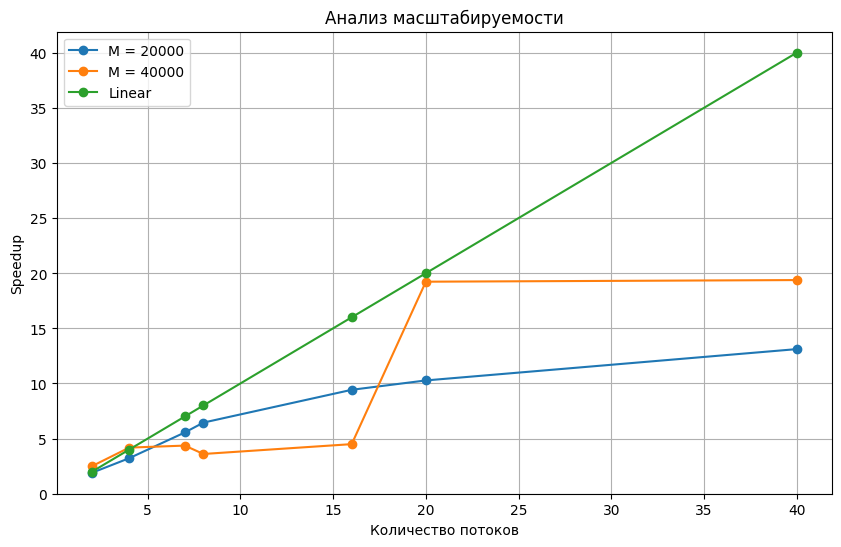

In [1]:
import matplotlib.pyplot as plt

# Потоки
threads = [2, 4, 7, 8, 16, 20, 40]

# Speedup для M = 20000
speedup_20000 = [1.899, 3.217, 5.552, 6.445, 9.421, 10.271, 13.112]

# Speedup для M = 40000
speedup_40000 = [2.502, 4.177, 4.360, 3.599, 4.493, 19.228, 19.376]

# Идеальная линейная масштабируемость
ideal = threads

plt.figure(figsize=(10, 6))

plt.plot(threads, speedup_20000, marker='o', label='M = 20000')
plt.plot(threads, speedup_40000, marker='o', label='M = 40000')
plt.plot(threads, ideal, marker='o', label='Linear')

plt.title("Анализ масштабируемости")
plt.xlabel("Количество потоков")
plt.ylabel("Speedup")
plt.grid(True)
plt.legend()

plt.show()

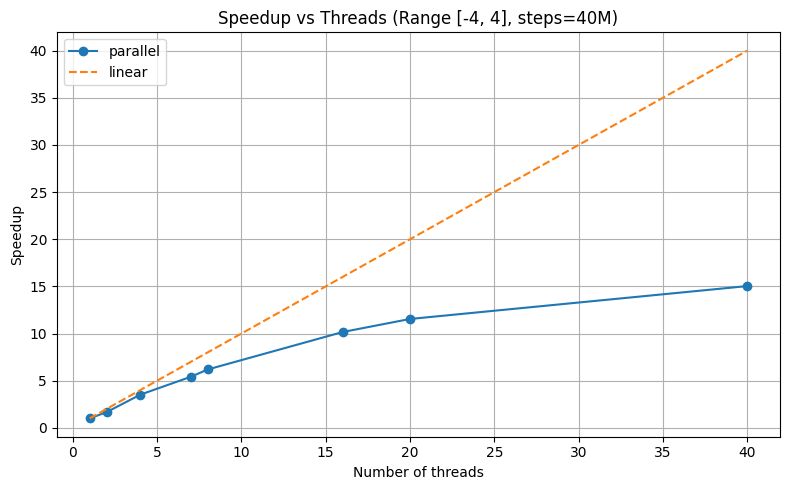

In [2]:
# Данные
threads = [1, 2, 4, 7, 8, 16, 20, 40]
times = [0.307542, 0.185752, 0.087702, 0.056952, 0.049836, 0.030355, 0.026707, 0.020509]

# Базовое время (serial ≈ OMP 1)
t1 = 0.308256

# Speedup (реальный)
speedup = [t1 / t for t in times]

# Линейный speedup (идеальный)
linear = threads

# Построение
plt.figure(figsize=(8, 5))

plt.plot(threads, speedup, 'o-', label='parallel')
plt.plot(threads, linear, '--', label='linear')

plt.xlabel('Number of threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads (Range [-4, 4], steps=40M)')

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

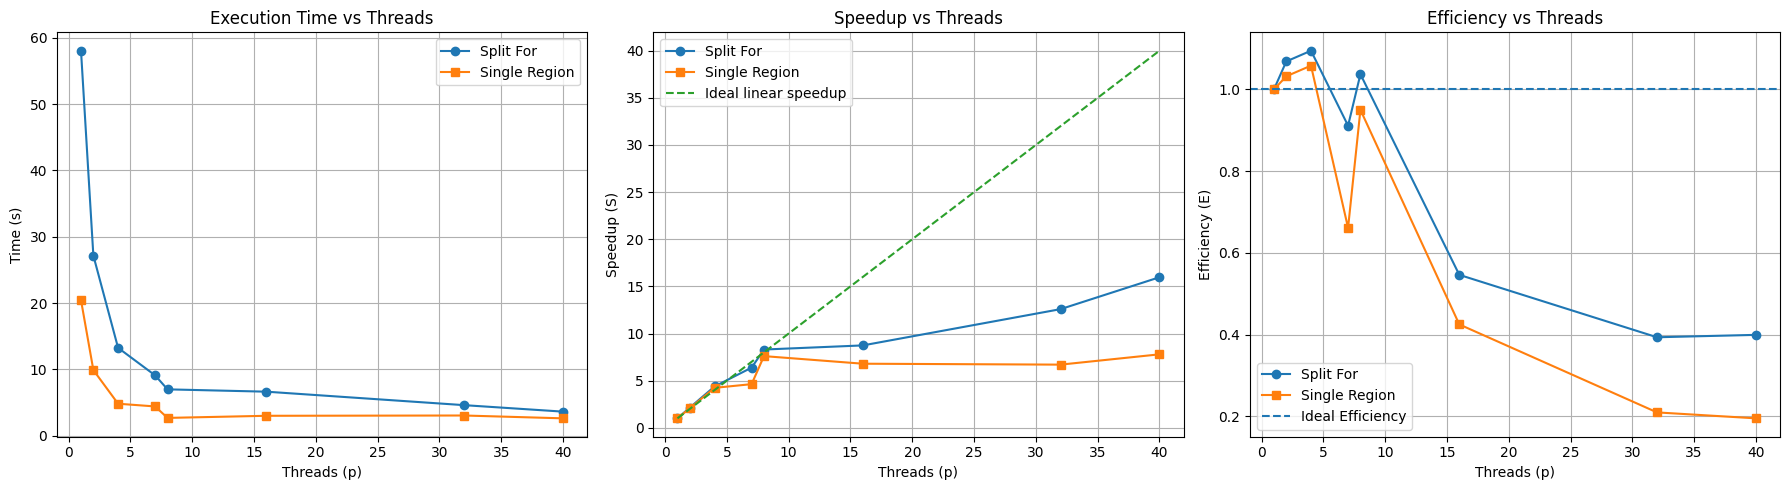

In [3]:
import matplotlib.pyplot as plt

# Потоки
threads = [1, 2, 4, 7, 8, 16, 32, 40]

# Время выполнения
split_for = [58.038084, 27.155239, 13.252142, 9.098217, 6.993395, 6.642720, 4.611810, 3.634925]
single_region = [20.437393, 9.899829, 4.827699, 4.415872, 2.688829, 3.007584, 3.051410, 2.623503]

# Базовое время (для speedup)
t1_split = split_for[0]
t1_single = single_region[0]

# Speedup
speedup_split = [t1_split / t for t in split_for]
speedup_single = [t1_single / t for t in single_region]

# Efficiency
eff_split = [s / p for s, p in zip(speedup_split, threads)]
eff_single = [s / p for s, p in zip(speedup_single, threads)]

# ====== ГРАФИКИ ======
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Execution Time ---
axs[0].plot(threads, split_for, 'o-', label='Split For')
axs[0].plot(threads, single_region, 's-', label='Single Region')
axs[0].set_title('Execution Time vs Threads')
axs[0].set_xlabel('Threads (p)')
axs[0].set_ylabel('Time (s)')
axs[0].grid(True)
axs[0].legend()

# --- 2. Speedup ---
axs[1].plot(threads, speedup_split, 'o-', label='Split For')
axs[1].plot(threads, speedup_single, 's-', label='Single Region')
axs[1].plot(threads, threads, '--', label='Ideal linear speedup')
axs[1].set_title('Speedup vs Threads')
axs[1].set_xlabel('Threads (p)')
axs[1].set_ylabel('Speedup (S)')
axs[1].grid(True)
axs[1].legend()

# --- 3. Efficiency ---
axs[2].plot(threads, eff_split, 'o-', label='Split For')
axs[2].plot(threads, eff_single, 's-', label='Single Region')
axs[2].axhline(1.0, linestyle='--', label='Ideal Efficiency')
axs[2].set_title('Efficiency vs Threads')
axs[2].set_xlabel('Threads (p)')
axs[2].set_ylabel('Efficiency (E)')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()